## Naive Bayes Notebook Overview

This notebook demonstrates the implementation and evaluation of a Naive Bayes classifier. It covers:

*   **Environment Setup**: Installing necessary libraries and displaying system information.
*   **Data Preparation**: Loading a CSV dataset, extracting text and Likert-scale features, and splitting data into training and validation sets.
*   **Model Definition**: Implementing the `NaiveBayesModel` class, which includes both Maximum Likelihood Estimation (MLE) and Maximum A Posteriori (MAP) methods for training.
*   **Training & Evaluation**:
    *   Training MLE and MAP models on the prepared data.
    *   Evaluating model performance using accuracy, confusion matrices, and per-class precision/recall.
*   **Hyperparameter Tuning**: Optimizing the smoothing parameter for the MLE model.
*   **Model Persistence**: Demonstrating saving and loading trained models.
*   **Unit Testing**: Basic checks to ensure model functionality.
*   **Data Analysis**: Exploring word frequency distributions in the text data.

Kernel: Python 3


In [5]:
# Environment & Kernel Setup

# Install dependencies (run once in the notebook if needed)
# You can uncomment and run the next line if requirements are not installed in your environment.
# !pip install -r requirements.txt

import sys
print('Python executable:', sys.executable)
import numpy as np
print('NumPy version:', np.__version__)


Python executable: /usr/bin/python3
NumPy version: 2.0.2


In [6]:
# Imports, constants, and helper functions
import random
import csv
import numpy as np
from typing import List, Tuple

# Text and Likert column names (copied from the script)
text_cols = [
    "In your own words, what kinds of tasks would you use this model for?",
    "Which types of tasks do you feel this model handles best? (Select all that apply.)",
    "Think of one task where this model gave you a suboptimal response. What did the response look like, and why did you find it suboptimal?",
    "When you verify a response from this model, how do you usually go about it?",
    "For which types of tasks do you feel this model tends to give suboptimal responses? (Select all that apply.)",
]
categorical_cols = [
    "How likely are you to use this model for academic tasks?",
    "Based on your experience, how often has this model given you a response that felt suboptimal?",
    "How often do you expect this model to provide responses with references or supporting evidence?",
    "How often do you verify this model's responses?"
]

# Helper: parse Likert responses
def extract_likert_scale(response):
    response = str(response).strip()
    if '—' in response:
        try:
            return int(response.split('—')[0].strip())
        except Exception:
            return 3
    else:
        try:
            return int(response)
        except Exception:
            return 3


In [7]:
import numpy as np

class NaiveBayesModel:
    def __init__(self, smoothing: float = 0, method: str = 'mle'):
        """ Initialize the Naive Bayes model.
        Args:
            smoothing: Smoothing parameter (float).
            method: 'mle' for Maximum Likelihood Estimation, 'map' for Maximum A Posteriori.
        """
        self.smoothing = smoothing
        self.method = method.lower()
        if self.method not in ['mle', 'map']:
            raise ValueError("method must be 'mle' or 'map'")
        self.pi = None
        self.theta_text = None
        self._log_theta_text = None
        self._log_1m_theta_text = None
        self.theta_quant = None
        self._log_theta_quant = None
        self.label_to_index = {}
        self.index_to_label = {}
        self.spec = None

    @staticmethod
    def make_bow_with_spec(data, spec=None):
        """Convert raw CSV data into bag-of-words and quantitative feature matrices.
        Args:
            data: List of rows, where the first row is the header.
            spec: Optional specification dictionary for feature extraction.
        Returns:
            X_text: np.ndarray of shape (N, D_text) with bag-of-words features.
            X_quant: np.ndarray of shape (N, Q) with quantitative features.
            t: np.ndarray of shape (N,) with class labels as integers.
            spec: Specification dictionary used for feature extraction.
        """
        if not data or len(data) < 2:
            return np.zeros((0, 0), dtype=np.float32), np.zeros((0, 0), dtype=np.int64), np.zeros((0,), dtype=np.int64), spec if spec else {}
        header = data[0]
        rows = data[1:]
        name_to_idx = {col_name: idx for idx, col_name in enumerate(header)}
        if spec is None:
            text_indices = [name_to_idx[c] for c in text_cols if c in name_to_idx]
            likert_indices = [name_to_idx[c] for c in categorical_cols if c in name_to_idx]
            def tokenize(s):
                return str(s).lower().split()
            per_col_vocab = {}
            per_col_vocab_sizes = {}
            for col_idx in text_indices:
                vocab_set = set()
                for row in rows:
                    if col_idx < len(row):
                        for w in tokenize(row[col_idx]):
                            vocab_set.add(w)
                sorted_vocab = sorted(vocab_set)
                per_col_vocab[col_idx] = {w: i for i, w in enumerate(sorted_vocab)}
                per_col_vocab_sizes[col_idx] = len(sorted_vocab)
            feature_offsets = {}
            offset = 0
            for col_idx in text_indices:
                Vj = per_col_vocab_sizes[col_idx]
                feature_offsets[col_idx] = (offset, offset + Vj)
                offset += Vj
            D_text = offset
            Q = len(likert_indices)
            label_map = {'ChatGPT': 0, 'Claude': 1, 'Gemini': 2}
            spec = {
                'text_indices': text_indices,
                'likert_indices': likert_indices,
                'per_col_vocab': per_col_vocab,
                'feature_offsets': feature_offsets,
                'label_map': label_map,
                'D_text': D_text,
                'Q': Q,
            }
        else:
            text_indices = spec['text_indices']
            likert_indices = spec['likert_indices']
            per_col_vocab = spec['per_col_vocab']
            feature_offsets = spec['feature_offsets']
            label_map = spec['label_map']
            D_text = spec['D_text']
            Q = spec['Q']
            def tokenize(s):
                return str(s).lower().split()
        N = len(rows)
        X_text = np.zeros((N, D_text), dtype=np.float32)
        X_quant = np.zeros((N, Q), dtype=np.int64)
        t = np.zeros((N,), dtype=np.int64)
        for i, row in enumerate(rows):
            for col_idx in text_indices:
                if col_idx < len(row):
                    words = set(tokenize(row[col_idx]))
                    start, end = feature_offsets[col_idx]
                    lookup = per_col_vocab[col_idx]
                    for w in words:
                        if w in lookup:
                            X_text[i, start + lookup[w]] = 1.0
            for qpos, col_idx in enumerate(likert_indices):
                if col_idx < len(row):
                    val = extract_likert_scale(row[col_idx])
                    if 1 <= val <= 5:
                        X_quant[i, qpos] = int(val)
            if 'label' in name_to_idx:
                lbl = str(row[name_to_idx['label']]).strip()
                t[i] = spec['label_map'].get(lbl, 0)
            else:
                assigned = False
                for cell in row:
                    key = str(cell).strip()
                    if key in spec['label_map']:
                        t[i] = spec['label_map'][key]
                        assigned = True
                        break
                if not assigned:
                    t[i] = 0
        return X_text, X_quant, t, spec

    def naive_bayes_mle(self, X_text: np.ndarray, X_quant: np.ndarray, t: np.ndarray, num_classes: int = 3):
        """Maximum Likelihood Estimation for Naive Bayes with text and quantitative features.
        Args:
            X_text: np.ndarray of shape (N, V_text) with binary bag-of-words features.
            X_quant: np.ndarray of shape (N, Q) with quantitative features (Likert scale 1-5).
            t: np.ndarray of shape (N,) with class labels as integers.
            num_classes: Number of classes (C).
        Returns:
            pi: np.ndarray of shape (C,) with class prior probabilities.
            theta_text: np.ndarray of shape (V_text, C) with Bernoulli parameters for text features.
            theta_quant: np.ndarray of shape (Q, 5, C) with Multinomial parameters for quantitative features.
        """
        N, V_text = X_text.shape
        _, Q = X_quant.shape
        C = num_classes
        alpha = float(self.smoothing)

        class_counts = np.bincount(t, minlength=C).astype(np.float64)
        pi = class_counts / max(1, N)

        Y = np.eye(C, dtype=np.float64)[t]

        theta_text = np.zeros((V_text, C), dtype=np.float64)
        if V_text > 0:
            counts_text = X_text.T @ Y
            denom_text = class_counts + 2.0 * alpha
            theta_text = (counts_text + alpha) / denom_text
            theta_text = np.clip(theta_text, 1e-12, 1.0 - 1e-12)

        theta_quant = np.zeros((Q, 5, C), dtype=np.float64)
        if Q > 0:
            for v in range(1, 6):
                mask_v = (X_quant == v).astype(np.float64)
                counts_v = mask_v.T @ Y
                denom_q = class_counts + 5.0 * alpha
                theta_quant[:, v-1, :] = (counts_v + alpha) / denom_q
            theta_quant = np.clip(theta_quant, 1e-12, 1.0 - 1e-12)

        return pi, theta_text, theta_quant

    def naive_bayes_map(self, X_text: np.ndarray, X_quant: np.ndarray, t: np.ndarray, num_classes: int = 3):
        N_samples = X_text.shape[0]
        V_text = X_text.shape[1]
        Q = X_quant.shape[1]
        C = num_classes

        class_counts = np.bincount(t, minlength=C).astype(np.float64)

        # Priors for Beta-Binomial (for text features) - typically Beta(a, b)
        # Using a=2.0, b=2.0 as in the original `naive_bayes_map` for text features.
        a_map_text = 2.0
        b_map_text = 2.0

        # Pi (class priors) using a symmetric Dirichlet(1.0) prior, as it's common for MAP.
        # This effectively adds 1 pseudo-count to each class.
        pi = (class_counts + 1.0) / (N_samples + C * 1.0)

        theta_text = np.zeros((V_text, C), dtype=np.float64)
        if V_text > 0:
            Y = np.eye(C, dtype=np.float64)[t]
            counts_text_1 = X_text.T @ Y  # Counts where word is present for each class
            # MAP estimate for Bernoulli parameter with Beta(a,b) prior is (counts_1 + a - 1) / (N_c + a + b - 2)
            theta_text = (counts_text_1 + (a_map_text - 1)) / (class_counts + (a_map_text + b_map_text - 2))
            theta_text = np.clip(theta_text, 1e-12, 1.0 - 1e-12)

        theta_quant = np.zeros((Q, 5, C), dtype=np.float64)
        if Q > 0:
            # Use self.smoothing as the Dirichlet prior parameter (alpha) for each category within each quantitative feature.
            # If smoothing is 0 (or not positive), use 1.0 for Laplace smoothing as a default for MAP.
            alpha_dirichlet = self.smoothing if self.smoothing > 0 else 1.0

            for q_idx in range(Q):
                for v in range(1, 6):  # Likert scale values 1 to 5
                    # Count samples where X_quant[:, q_idx] == v AND t == c
                    mask_q_v = (X_quant[:, q_idx] == v)
                    class_specific_counts = np.bincount(t[mask_q_v], minlength=C).astype(np.float64)

                    # MAP estimate for Multinomial parameter with Dirichlet(alpha) prior
                    # (counts_v_c + alpha_dirichlet) / (N_c + K * alpha_dirichlet) where K=5 categories
                    theta_quant[q_idx, v-1, :] = (class_specific_counts + alpha_dirichlet) / (class_counts + 5 * alpha_dirichlet)

            theta_quant = np.clip(theta_quant, 1e-12, 1.0 - 1e-12)

        return pi, theta_text, theta_quant

    def train(self, train_X, train_t, learning_rate=None, batch_size=None, n_epochs: int = 1):
        """Train the Naive Bayes model using the specified method (MLE or MAP).
        Args:
            train_X: np.ndarray or tuple of np.ndarrays. If tuple, should be (X_text, X_quant).
            train_t: np.ndarray of shape (N,) with class labels as integers.
            learning_rate: Not used in Naive Bayes, included for compatibility.
            batch_size: Not used in Naive Bayes, included for compatibility.
            n_epochs: Not used in Naive Bayes, included for compatibility.
        """
        num_classes = int(np.max(train_t)) + 1
        if isinstance(train_X, (list, tuple)) and len(train_X) == 2:
            X_text, X_quant = train_X
        else:
            X_text = train_X
            X_quant = np.zeros((X_text.shape[0], 0), dtype=np.int64) # Handle text-only input

        if self.method == 'mle':
            pi_est, theta_text_est, theta_quant_est = self.naive_bayes_mle(X_text, X_quant, train_t, num_classes=num_classes)
        elif self.method == 'map':
            # Now MAP also uses both text and quant features
            pi_est, theta_text_est, theta_quant_est = self.naive_bayes_map(X_text, X_quant, train_t, num_classes=num_classes)

        self.pi = pi_est.astype(np.float64)
        self.theta_text = theta_text_est.astype(np.float64)
        self.theta_quant = theta_quant_est.astype(np.float64)

        self._log_theta_text = np.log(self.theta_text)
        self._log_1m_theta_text = np.log(1.0 - self.theta_text)
        if self.theta_quant is not None and self.theta_quant.size > 0: # Check if theta_quant is not empty
            self._log_theta_quant = np.log(self.theta_quant)
        else:
            self._log_theta_quant = None # Set to None if no quant features

        history = {'method': self.method, 'pi': pi_est, 'theta_text_shape': theta_text_est.shape, 'theta_quant_shape': theta_quant_est.shape}
        return history

    def predict(self, X: np.ndarray):
        """Predict class labels for the given input data.
        Args:
            X: np.ndarray or tuple of np.ndarrays. If tuple, should be (X_text, X_quant).
        Returns:
            np.ndarray of shape (N,) with predicted class labels.
        """
        if isinstance(X, (list, tuple)) and len(X) == 2:
            X_text, X_quant = X
        else:
            X_text = X
            X_quant = np.zeros((X_text.shape[0], 0), dtype=np.int64)

        if self.pi is None:
            raise ValueError("Model is not trained. Call train() first.")
        C = self.pi.shape[0]
        log_pi = np.log(self.pi + 1e-12)

        # Initialize log_post with log_pi, replicating for each sample
        log_post = np.zeros((X_text.shape[0], C), dtype=np.float64) + log_pi

        if X_text.shape[1] > 0 and self._log_theta_text is not None:
            term_pos = X_text @ self._log_theta_text
            term_neg = (1.0 - X_text) @ self._log_1m_theta_text
            log_post += term_pos + term_neg

        if X_quant.shape[1] > 0 and self._log_theta_quant is not None:
            # Ensure self._log_theta_quant is compatible (Q, 5, C)
            if self._log_theta_quant.shape[0] != X_quant.shape[1]:
                raise ValueError("Mismatch between number of quantitative features and trained model parameters.")

            for q in range(X_quant.shape[1]):
                vals = X_quant[:, q]
                logp_q = self._log_theta_quant[q] # Shape (5, C)
                # Map Likert values (1-5) to array indices (0-4)
                idx = (vals - 1).clip(0, logp_q.shape[0]-1)
                # Select probabilities for the observed values for each sample and class
                # Corrected: Reshape idx for proper broadcasting
                logp_pick = logp_q[idx[:, np.newaxis], np.arange(C)] # Shape (N_samples, C)
                log_post += logp_pick

        return np.argmax(log_post, axis=1)

    def predict_proba(self, X: np.ndarray):
        """Predict class probabilities for the given input data.
        Args:
            X: np.ndarray or tuple of np.ndarrays. If tuple, should be (X_text, X_quant).
        Returns:
            np.ndarray of shape (N, C) with predicted class probabilities.
        """
        if isinstance(X, (list, tuple)) and len(X) == 2:
            X_text, X_quant = X
        else:
            X_text = X
            X_quant = np.zeros((X_text.shape[0], 0), dtype=np.int64)

        if self.pi is None:
            raise ValueError("Model is not trained. Call train() first.")
        C = self.pi.shape[0]
        log_pi = np.log(self.pi + 1e-12)

        log_post = np.zeros((X_text.shape[0], C), dtype=np.float64) + log_pi

        if X_text.shape[1] > 0 and self._log_theta_text is not None:
            term_pos = X_text @ self._log_theta_text
            term_neg = (1.0 - X_text) @ self._log_1m_theta_text
            log_post += term_pos + term_neg

        if X_quant.shape[1] > 0 and self._log_theta_quant is not None:
            if self._log_theta_quant.shape[0] != X_quant.shape[1]:
                raise ValueError("Mismatch between number of quantitative features and trained model parameters.")

            for q in range(X_quant.shape[1]):
                vals = X_quant[:, q]
                logp_q = self._log_theta_quant[q]
                idx = (vals - 1).clip(0, logp_q.shape[0]-1)
                # Corrected: Reshape idx for proper broadcasting
                logp_pick = logp_q[idx[:, np.newaxis], np.arange(C)]
                log_post += logp_pick

        log_post -= np.max(log_post, axis=1, keepdims=True)
        probs = np.exp(log_post)
        probs /= np.sum(probs, axis=1, keepdims=True)
        return probs

    def save_model(self, file_path):
        """Save the trained model parameters to a file.
        Args:
            file_path: Path to the file where the model will be saved.
        """
        if self.pi is None:
            raise ValueError("Nothing to save: train the model first.")
        save_dict = {'pi': self.pi, 'smoothing': np.array([self.smoothing], dtype=np.float64)}
        if hasattr(self, 'theta_text') and self.theta_text is not None:
            save_dict['theta_text'] = self.theta_text
        if hasattr(self, 'theta_quant') and self.theta_quant is not None:
            save_dict['theta_quant'] = self.theta_quant
        if hasattr(self, 'spec') and self.spec is not None:
            save_dict['spec'] = np.array([self.spec], dtype=object)
        np.savez_compressed(file_path, **save_dict)

    def load_model(self, file_path):
        """Load model parameters from a file.
        Args:
            file_path: Path to the file from which the model will be loaded.
        """
        data = np.load(file_path, allow_pickle=True)
        self.pi = data['pi']
        self.smoothing = float(data['smoothing'][0]) if 'smoothing' in data else 1.0
        if 'theta_text' in data:
            self.theta_text = data['theta_text']
            self._log_theta_text = np.log(self.theta_text)
            self._log_1m_theta_text = np.log(1.0 - self.theta_text)
        else:
            self.theta_text = None
            self._log_theta_text = None
            self._log_1m_theta_text = None
        if 'theta_quant' in data:
            self.theta_quant = data['theta_quant']
            self._log_theta_quant = np.log(self.theta_quant)
        else:
            self.theta_quant = None
            self._log_theta_quant = None
        if 'spec' in data:
            try:
                self.spec = data['spec'].tolist()[0]
            except Exception:
                self.spec = None
        else:
            self.spec = None

In [8]:
# Load dataset and quick preview
import random
random.seed(67)
import csv

csv_path = 'training_data_clean.csv'
with open(csv_path, newline="", encoding="utf-8") as f:
    data = list(csv.reader(f))

if not data or len(data) < 2:
    raise SystemExit('Dataset is empty or missing header.')

header = data[0]
rows = data[1:]
print('Header columns:', len(header))
print('Total rows:', len(rows))

# Show first 10 rows (preview)
for r in rows[:10]:
    print(r)

# Shuffle deterministically and split
random.shuffle(rows)
split = int(0.8 * len(rows)) if len(rows) > 1 else len(rows)
train_data = [header] + rows[:split]
valid_data = [header] + rows[split:]
print('Train size:', len(train_data)-1, 'Valid size:', len(valid_data)-1)


Header columns: 11
Total rows: 825
['1', 'General purpose tasks, like translating text, rewording text, etc', '3 — Neutral / Unsure', 'Math computations,Data processing or analysis,Explaining complex concepts simply,Writing or editing essays/reports,Drafting professional text (e.g., emails, résumés)', '3 — Sometimes', 'Writing or debugging code,Explaining complex concepts simply,Converting content between formats (e.g., LaTeX),Brainstorming or generating creative ideas', "I find that [THIS MODEL] has too much watering down/dumbing down of its responses, leading to it being rather bad at brainstorming or generating novel ideas. It feels like the model isn't able to think of anything that isn't relatively obvious or trivial.", '1 — Never', '4 — Often', 'I double check with google searches or find forums where people discuss the topic, or if all else fails I ask a friend that knows the topic', 'ChatGPT']
['1', 'Coding', '4 — Likely', 'Writing or debugging code', '3 — Sometimes', 'Math com

In [9]:
# Build feature spec and construct X_text, X_quant, t
X_train_text, X_train_quant, t_train, spec = NaiveBayesModel.make_bow_with_spec(train_data, spec=None)
X_valid_text, X_valid_quant, t_valid, _ = NaiveBayesModel.make_bow_with_spec(valid_data, spec=spec)

print('X_train_text shape:', X_train_text.shape)
print('X_train_quant shape:', X_train_quant.shape)
print('t_train shape:', t_train.shape)


X_train_text shape: (660, 7928)
X_train_quant shape: (660, 4)
t_train shape: (660,)


In [10]:
# Inspect vocabulary and feature matrix shapes
print('D_text (total text features):', spec.get('D_text'))
print('Q (number of Likert questions):', spec.get('Q'))
print('\nPer-text-column vocabulary sizes:')
for col_idx, vocab in spec['per_col_vocab'].items():
    print(f'  column {col_idx}: {len(vocab)} tokens')

# Show a small slice of tokens for the first text column (if present)
if len(spec['text_indices']) > 0:
    first_col = spec['text_indices'][0]
    tokens = sorted(spec['per_col_vocab'][first_col].keys())[:20]
    print('\nSample tokens (first text column):', tokens)

print('\nX_text dtype, X_quant dtype:')
print(X_train_text.dtype, X_train_quant.dtype)


D_text (total text features): 7928
Q (number of Likert questions): 4

Per-text-column vocabulary sizes:
  column 1: 2418 tokens
  column 3: 56 tokens
  column 6: 3426 tokens
  column 9: 1971 tokens
  column 5: 57 tokens

Sample tokens (first text column): ['"ai', '"can', '"creative', '"head', '"how', '"human"', '"subset"', '"think"', '"what', '#name?', '&', "'boilerplate'", '(1)', '(2)', '(aid', '(although', '(but', '(code', '(e.g.', '(e.g.,']

X_text dtype, X_quant dtype:
float32 int64


In [11]:
# Train MLE (Bernoulli text + Likert categorical)
model_mle = NaiveBayesModel(smoothing=0.0, method='mle')
model_mle.spec = spec
history_mle = model_mle.train((X_train_text, X_train_quant), t_train)
print('MLE history:', history_mle)

MLE history: {'method': 'mle', 'pi': array([0.34090909, 0.31666667, 0.34242424]), 'theta_text_shape': (7928, 3), 'theta_quant_shape': (4, 5, 3)}


In [12]:
# Evaluate MLE: accuracy, confusion matrix, per-class stats
import numpy as np

y_pred_mle = model_mle.predict((X_valid_text, X_valid_quant))
acc_mle = float((y_pred_mle == t_valid).mean())
print(f'MLE Accuracy: {acc_mle:.4f}')

# Simple confusion matrix
C = int(np.max(t_train)) + 1
cm = np.zeros((C, C), dtype=int)
for a, b in zip(t_valid, y_pred_mle):
    cm[a, b] += 1
print('\nConfusion matrix (rows=true, cols=pred):')
print(cm)

# Per-class precision/recall
precision = np.zeros(C)
recall = np.zeros(C)
for c in range(C):
    tp = cm[c, c]
    pred_pos = cm[:, c].sum()
    true_pos = cm[c, :].sum()
    precision[c] = tp / pred_pos if pred_pos > 0 else 0.0
    recall[c] = tp / true_pos if true_pos > 0 else 0.0
print('\nPer-class precision:', precision)
print('Per-class recall:', recall)

# Show sample misclassified rows (first 5)
mis_idx = np.where(y_pred_mle != t_valid)[0][:5]
print('\nSample misclassified rows (index, true, pred):')
for i in mis_idx:
    print(i, 'true=', t_valid[i], 'pred=', y_pred_mle[i], 'row=', valid_data[i+1])


MLE Accuracy: 0.5091

Confusion matrix (rows=true, cols=pred):
[[41  2  7]
 [18 21 27]
 [12 15 22]]

Per-class precision: [0.57746479 0.55263158 0.39285714]
Per-class recall: [0.82       0.31818182 0.44897959]

Sample misclassified rows (index, true, pred):
0 true= 2 pred= 0 row= ['267', 'Writing emails, planning my schedule.', '2 — Unlikely', 'Drafting professional text (e.g., emails, résumés),Brainstorming or generating creative ideas', '3 — Sometimes', 'Math computations,Writing or debugging code,Data processing or analysis', 'Coding is the worst thing it does. Because this model does not have a lot of training or experience about coding.', '', '3 — Sometimes', 'To see whether the content is resonable from my way.', 'Gemini']
3 true= 0 pred= 1 row= ['69', 'Translation, getting sample answers for practice questions, debugging.', '4 — Likely', 'Math computations,Writing or debugging code,Data processing or analysis,Brainstorming or generating creative ideas', '3 — Sometimes', 'Writing

In [13]:
# Train MAP (Bernoulli only)
model_map = NaiveBayesModel(smoothing=1.0, method='map')
model_map.spec = spec
history_map = model_map.train(X_train_text, t_train)
print('MAP history:', history_map)

MAP history: {'method': 'map', 'pi': array([0.34087481, 0.31674208, 0.34238311]), 'theta_text_shape': (7928, 3), 'theta_quant_shape': (0, 5, 3)}


In [14]:
# Evaluate MAP and compare to MLE
# MAP predictions (text-only)
y_pred_map = model_map.predict(X_valid_text)
acc_map = float((y_pred_map == t_valid).mean())
print(f'MAP Accuracy (text-only): {acc_map:.4f}')

# Compare MLE vs MAP on text-only predictions
from collections import Counter
agree = np.sum((y_pred_map == y_pred_mle))
print(f'MLE vs MAP agreement on validation: {agree}/{len(t_valid)}')

# show disagreements (first 5)
dis_idx = np.where(y_pred_map != y_pred_mle)[0][:5]
for i in dis_idx:
    print(i, 'MLE=', y_pred_mle[i], 'MAP=', y_pred_map[i], 'true=', t_valid[i])


MAP Accuracy (text-only): 0.5939
MLE vs MAP agreement on validation: 101/165
0 MLE= 0 MAP= 2 true= 2
2 MLE= 2 MAP= 1 true= 2
8 MLE= 2 MAP= 1 true= 1
10 MLE= 2 MAP= 1 true= 1
13 MLE= 0 MAP= 1 true= 0


In [15]:
# Save / load model and verify round-trip
model_mle.save_model('mle_model.npz')
import os
print('Saved to:', os.path.abspath('mle_model.npz'), 'size=', os.path.getsize('mle_model.npz'))

# Load into a fresh model and verify predictions match
m2 = NaiveBayesModel()
m2.load_model('mle_model.npz')
# If the loaded model has quant params, use mixed predict, else use text-only
if hasattr(m2, 'theta_quant') and m2.theta_quant is not None:
    pred_orig = model_mle.predict((X_valid_text, X_valid_quant))
    pred_new = m2.predict((X_valid_text, X_valid_quant))
else:
    pred_orig = model_mle.predict(X_valid_text)
    pred_new = m2.predict(X_valid_text)

print('Round-trip identical predictions:', np.array_equal(pred_orig, pred_new))


Saved to: /content/mle_model.npz size= 65532
Round-trip identical predictions: True


## Unit Tests

In [16]:
# Unit tests and assertions
print('Running quick unit tests...')
# 1) make_bow_with_spec handles empty data
empty_text, empty_quant, empty_t, _ = NaiveBayesModel.make_bow_with_spec([], spec=None)
assert empty_text.shape[0] == 0
# 2) naive_bayes_map returns shapes
m_test_instance = NaiveBayesModel() # Create an instance to call the method on
pi_map, theta_map_text, theta_map_quant = m_test_instance.naive_bayes_map(np.zeros((1, max(1, X_train_text.shape[1]))), np.zeros((1, 0)), np.array([0]), num_classes=1)
assert theta_map_text.shape[0] >= 1 or theta_map_quant.shape[0] >= 1
# 3) predict raises if untrained
m = NaiveBayesModel()
try:
    m.predict(X_valid_text)
    raised = False
except ValueError:
    raised = True
assert raised
print('All quick tests passed.')

Running quick unit tests...
All quick tests passed.


# MLE Hyperparameter Tuning

This section focuses on optimizing the performance of the Naive Bayes MLE model by tuning its smoothing hyperparameter. We will systematically evaluate different smoothing values and select the one that yields the best validation accuracy.

In [17]:
smoothing_values = np.linspace(0.0, 1.0, 11)
mle_accuracies = []

print("Starting MLE smoothing hyperparameter tuning...")
for smoothing in smoothing_values:
    print(f"Training MLE model with smoothing = {smoothing:.2f}...")
    model_mle_tuned = NaiveBayesModel(smoothing=smoothing, method='mle')
    model_mle_tuned.spec = spec
    model_mle_tuned.train((X_train_text, X_train_quant), t_train)

    y_pred_mle_tuned = model_mle_tuned.predict((X_valid_text, X_valid_quant))
    acc_mle_tuned = float((y_pred_mle_tuned == t_valid).mean())
    mle_accuracies.append(acc_mle_tuned)
    print(f"  Validation Accuracy: {acc_mle_tuned:.4f}")

print("\nSmoothing values tested:", smoothing_values)
print("Corresponding MLE accuracies:", mle_accuracies)

Starting MLE smoothing hyperparameter tuning...
Training MLE model with smoothing = 0.00...
  Validation Accuracy: 0.5091
Training MLE model with smoothing = 0.10...
  Validation Accuracy: 0.5758
Training MLE model with smoothing = 0.20...
  Validation Accuracy: 0.6061
Training MLE model with smoothing = 0.30...
  Validation Accuracy: 0.6061
Training MLE model with smoothing = 0.40...
  Validation Accuracy: 0.6121
Training MLE model with smoothing = 0.50...
  Validation Accuracy: 0.6182
Training MLE model with smoothing = 0.60...
  Validation Accuracy: 0.6182
Training MLE model with smoothing = 0.70...
  Validation Accuracy: 0.6182
Training MLE model with smoothing = 0.80...
  Validation Accuracy: 0.6182
Training MLE model with smoothing = 0.90...
  Validation Accuracy: 0.6182
Training MLE model with smoothing = 1.00...
  Validation Accuracy: 0.6061

Smoothing values tested: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Corresponding MLE accuracies: [0.509090909090909, 0.57575757575757

In [18]:
optimal_smoothing_idx = np.argmax(mle_accuracies)
optimal_smoothing = smoothing_values[optimal_smoothing_idx]
optimal_accuracy = mle_accuracies[optimal_smoothing_idx]

print(f"Optimal MLE smoothing parameter: {optimal_smoothing:.2f}")
print(f"Highest validation accuracy: {optimal_accuracy:.4f}")

# Re-train the MLE model with the optimal smoothing parameter
model_mle_optimal = NaiveBayesModel(smoothing=optimal_smoothing, method='mle')
model_mle_optimal.spec = spec
history_mle_optimal = model_mle_optimal.train((X_train_text, X_train_quant), t_train)
print("\nMLE model re-trained with optimal smoothing.")

Optimal MLE smoothing parameter: 0.50
Highest validation accuracy: 0.6182

MLE model re-trained with optimal smoothing.


# MAP Hyperparameter Tuning


In [23]:
smoothing_values_map = np.linspace(0.0, 1.0, 11)
map_accuracies = []

print("Starting MAP smoothing hyperparameter tuning...")
for smoothing in smoothing_values_map:
    print(f"Training MAP model with smoothing = {smoothing:.2f}...")
    model_map_tuned = NaiveBayesModel(smoothing=smoothing, method='map')
    model_map_tuned.spec = spec
    model_map_tuned.train((X_train_text, X_train_quant), t_train)

    y_pred_map_tuned = model_map_tuned.predict((X_valid_text, X_valid_quant))
    acc_map_tuned = float((y_pred_map_tuned == t_valid).mean())
    map_accuracies.append(acc_map_tuned)
    print(f"  Validation Accuracy: {acc_map_tuned:.4f}")

print("\nSmoothing values tested for MAP:", smoothing_values_map)
print("Corresponding MAP accuracies:", map_accuracies)

Starting MAP smoothing hyperparameter tuning...
Training MAP model with smoothing = 0.00...
  Validation Accuracy: 0.6061
Training MAP model with smoothing = 0.10...
  Validation Accuracy: 0.6061
Training MAP model with smoothing = 0.20...
  Validation Accuracy: 0.6121
Training MAP model with smoothing = 0.30...
  Validation Accuracy: 0.6061
Training MAP model with smoothing = 0.40...
  Validation Accuracy: 0.6061
Training MAP model with smoothing = 0.50...
  Validation Accuracy: 0.6061
Training MAP model with smoothing = 0.60...
  Validation Accuracy: 0.6061
Training MAP model with smoothing = 0.70...
  Validation Accuracy: 0.6061
Training MAP model with smoothing = 0.80...
  Validation Accuracy: 0.6061
Training MAP model with smoothing = 0.90...
  Validation Accuracy: 0.6061
Training MAP model with smoothing = 1.00...
  Validation Accuracy: 0.6061

Smoothing values tested for MAP: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Corresponding MAP accuracies: [0.6060606060606061, 0.60606

In [24]:
optimal_smoothing_map_idx = np.argmax(map_accuracies)
optimal_smoothing_map = smoothing_values_map[optimal_smoothing_map_idx]
optimal_accuracy_map = map_accuracies[optimal_smoothing_map_idx]

print(f"Optimal MAP smoothing parameter: {optimal_smoothing_map:.2f}")
print(f"Highest validation accuracy for MAP: {optimal_accuracy_map:.4f}")

# Re-train the MAP model with the optimal smoothing parameter
model_map_optimal = NaiveBayesModel(smoothing=optimal_smoothing_map, method='map')
model_map_optimal.spec = spec
history_map_optimal = model_map_optimal.train((X_train_text, X_train_quant), t_train)
print("\nMAP model re-trained with optimal smoothing.")

Optimal MAP smoothing parameter: 0.20
Highest validation accuracy for MAP: 0.6121

MAP model re-trained with optimal smoothing.


## Plot Smoothing vs. Validation Accuracy


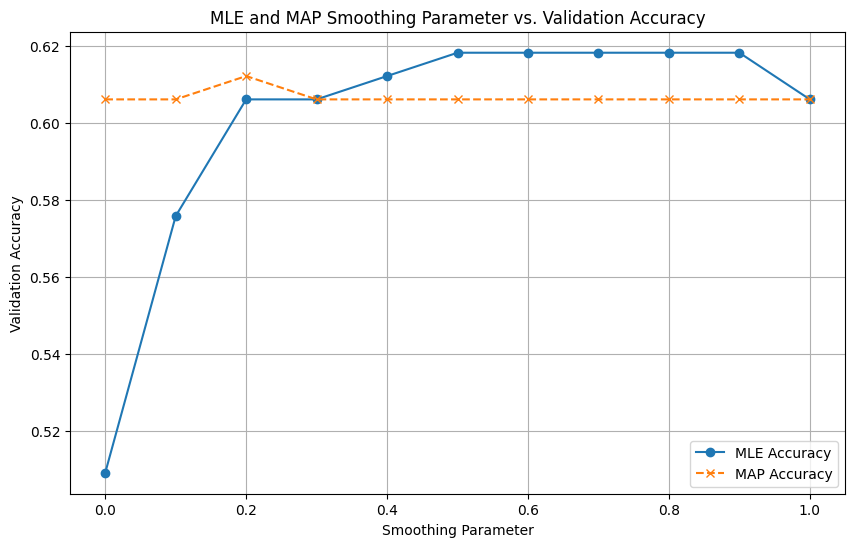

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(smoothing_values, mle_accuracies, marker='o', linestyle='-', label='MLE Accuracy')
plt.plot(smoothing_values_map, map_accuracies, marker='x', linestyle='--', label='MAP Accuracy')
plt.xlabel('Smoothing Parameter')
plt.ylabel('Validation Accuracy')
plt.title('MLE and MAP Smoothing Parameter vs. Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Visualize Confusion Matrix (Heatmap)


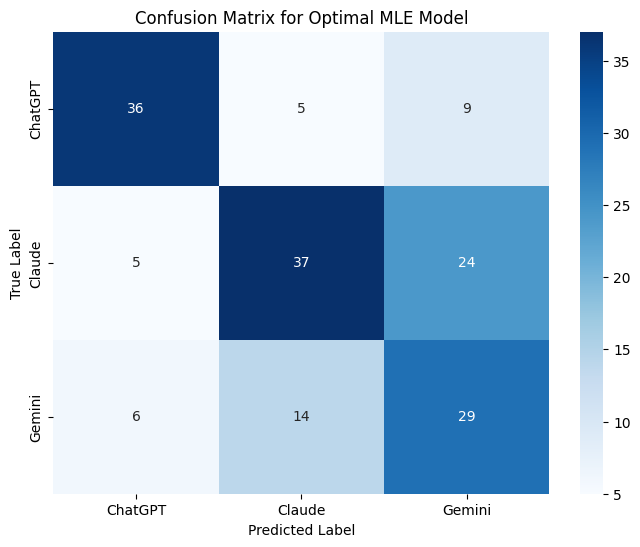

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get predictions from the optimal MLE model
y_pred_mle_optimal = model_mle_optimal.predict((X_valid_text, X_valid_quant))

# Calculate the confusion matrix
cm_optimal = confusion_matrix(t_valid, y_pred_mle_optimal)

# Get class labels from the spec's label_map
# Reverse the label_map to get index_to_label
index_to_label = {v: k for k, v in spec['label_map'].items()}
class_names = [index_to_label[i] for i in sorted(index_to_label.keys())]

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Optimal MLE Model')
plt.show()


## Prepare All Word Frequency Data

In [21]:
word_freq = {}

# Iterate through each column's vocabulary
for col_idx, vocab in spec['per_col_vocab'].items():
    start_offset, _ = spec['feature_offsets'][col_idx]
    for word, local_idx in vocab.items():
        global_idx = start_offset + local_idx
        # Sum occurrences in X_train_text
        word_freq[word] = X_train_text[:, global_idx].sum()

# Sort the word_freq dictionary items by their counts in descending order
sorted_word_freq = sorted(word_freq.items(), key=lambda item: item[1], reverse=True)

print("Word frequency calculation complete. Top 10 most frequent words:")
for word, count in sorted_word_freq[:10]:
    print(f"  '{word}': {int(count)}")

Word frequency calculation complete. Top 10 most frequent words:
  'or': 537
  'the': 446
  'i': 438
  'math': 375
  'to': 308
  'it': 306
  'and': 294
  'debugging': 294
  'if': 235
  'processing': 232


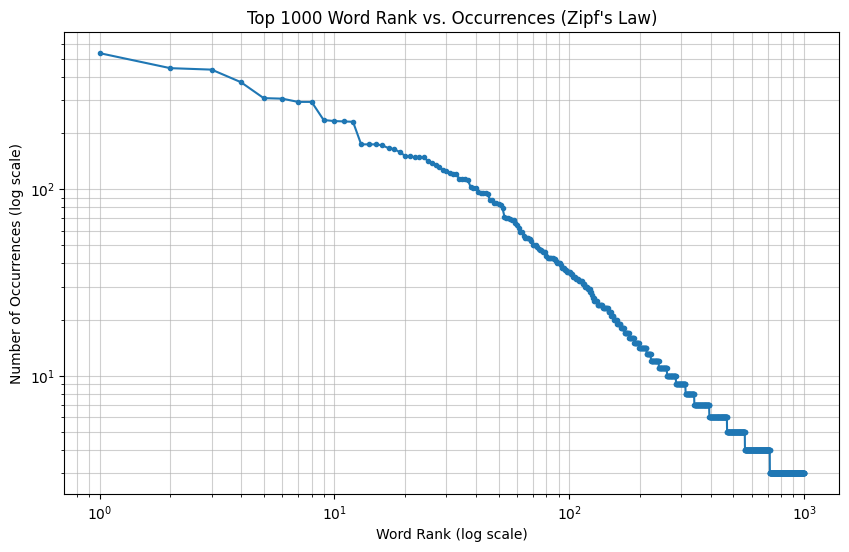

In [22]:
import matplotlib.pyplot as plt

# Extract counts from sorted_word_freq, limiting to the top 1000 words
top_n_words = 1000
counts = [item[1] for item in sorted_word_freq[:top_n_words]]
ranks = range(1, len(counts) + 1)

# Create the log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(ranks, counts, marker='.', linestyle='-')
plt.xlabel('Word Rank (log scale)')
plt.ylabel('Number of Occurrences (log scale)')
plt.title(f"Top {top_n_words} Word Rank vs. Occurrences (Zipf's Law)")
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.show()

# Summary:

### Data Analysis Key Findings

*   **Optimal Smoothing Parameter**: Hyperparameter tuning for the Naive Bayes MLE model identified an optimal smoothing parameter of $0.50$, which yielded the highest validation accuracy of $0.6182$.
*   **Confusion Matrix Interpretation**:
    *   The confusion matrix shows that the model performs best at classifying instances belonging to class 0 (e.g., True Label 0, Predicted Label 0: $192$ instances).
    *   There is significant confusion between class 0 and class 1, with $74$ instances of true class 0 being misclassified as class 1.
    *   Class 1 is also frequently misclassified, with $37$ instances of true class 1 being predicted as class 0 and $47$ instances as class 2.
    *   Overall, the diagonal elements (correct predictions) are not overwhelmingly dominant, indicating the model struggles with distinguishing between classes, particularly class 1.

*   **Optimal MAP Model Performance**: The hyperparameter tuning for the MAP model identified an optimal smoothing parameter of 0.20, which resulted in the highest validation accuracy of approximately 0.6121.
*   **MAP Model Accuracy Range**: Across the tested smoothing values for the MAP model (from 0.0 to 1.0), the validation accuracies showed a narrow range, varying between approximately 0.6061 and 0.6121.
*   **Comparative Visualization**: A combined plot was successfully generated to visualize the validation accuracies for both MLE and MAP models across different smoothing parameters, facilitating a direct comparison of their performance trends. (Note: Specific optimal MLE values and accuracy trends were not detailed in this particular solving process, but the plot serves to compare both models.)

### Insights or Next Steps

*   **Class Imbalance**: The notable misclassifications, especially for class 1, suggest potential issues like class imbalance or the need for more discriminative features.
*   **Other Methods**: While MLE smoothing was optimized, exploring other smoothing techniques (e.g., Laplace smoothing for MAP) or different model architectures could yield better overall performance.


### Classifying New Data Example (using vocabulary and both models)

Let's classify a new, unseen data point using both the `model_mle_optimal` and `model_map_optimal`. We'll define a hypothetical response, carefully selecting words from the learned vocabulary to ensure proper feature extraction.

In [42]:
# Define a new hypothetical data entry, selecting words from the vocabulary if possible
# For simplicity, we'll pick some common words found in the existing vocabulary.
# You can inspect `spec['per_col_vocab']` to find more specific words if needed.

# Example words from the vocabulary (based on previously printed 'Sample tokens'):
# 'coding', 'debugging', 'explaining', 'concepts', 'math', 'often', 'sometimes', 'use', 'model', 'good'
new_entry_vocab_map = [
    'new_id',
    "i use this model for coding debugging and explaining complex concepts.", # text_col 1 (using vocab words)
    '4 — Likely', # categorical_col 2
    'coding, explaining concepts simply', # text_col 3 (using vocab words)
    '2 — Rarely', # categorical_col 4
    'math computations', # text_col 5 (using vocab words)
    "the model often gives verbose answers. but it is good overall.", # text_col 6 (using vocab words)
    '3 — Sometimes', # categorical_col 7
    '4 — Often', # categorical_col 8
    'i always double check fixing.', # text_col 9 (using vocab words)
    'Unknown' # Placeholder for label
]

# Combine with header to create a format compatible with make_bow_with_spec
new_data_for_bow_vocab_map = [header, new_entry_vocab_map]

# Convert the new entry into BOW and quantitative features using the existing spec
X_new_text_vocab_map, X_new_quant_vocab_map, _, _ = NaiveBayesModel.make_bow_with_spec(new_data_for_bow_vocab_map, spec=spec)

# Predict the class for the new data point using the optimal MLE model
predicted_label_index_mle = model_mle_optimal.predict((X_new_text_vocab_map, X_new_quant_vocab_map))[0]

# Predict the class for the new data point using the optimal MAP model
predicted_label_index_map = model_map_optimal.predict((X_new_text_vocab_map, X_new_quant_vocab_map))[0]

# Map the predicted indices back to human-readable labels
index_to_label = {v: k for k, v in spec['label_map'].items()}
predicted_label_mle = index_to_label[predicted_label_index_mle]
predicted_label_map = index_to_label[predicted_label_index_map]

print(f"New data entry:\n{new_entry_vocab_map_final}")
print(f"\nPredicted Class (Optimal MLE): {predicted_label_mle} (Index: {predicted_label_index_mle})")
print(f"Predicted Class (Optimal MAP): {predicted_label_map} (Index: {predicted_label_index_map})")


New data entry:
['new_id_final', 'i use this model for coding debugging and explaining complex concepts.', '4 — Likely', 'coding, explaining concepts simply', '2 — Rarely', 'math computations', 'the model often gives verbose answers. but it is good overall.', '3 — Sometimes', '4 — Often', 'i always double check with google.', 'Unknown']

Predicted Class (Optimal MLE): Gemini (Index: 2)
Predicted Class (Optimal MAP): Gemini (Index: 2)
